# Golem Grad Tortoise Data

This project’s dataset comes from a fascinating ecological study titled **“Sex Ratio Bias Triggers Demographic Suicide in a Dense Tortoise Population.”** 

The story behind the data is so unusual that it caught the attention of major media outlets such as The New York Times, which published an article titled **“Constant Sexual Aggression Drives Female Tortoises to Walk Off Cliffs.”**

The study focuses on a population of Hermann's tortoise living on a small island called Golem Grad in Lake Prespa, located in North Macedonia. This island hosts an exceptionally dense tortoise population where the number of males greatly exceeds the number of females.
Because of this imbalance, females experience intense and frequent mating attempts from males. The constant harassment leads to severe injuries, exhaustion, and reduced reproductive success. In some cases, females attempt to escape the aggressive males by moving toward the edges of the island’s rocky cliffs—sometimes falling to their deaths.

The consequences are serious for the population. Compared to tortoises living on the nearby mainland, island females are often in poorer physical condition. They tend to have lower body mass, reproduce less frequently, produce smaller clutches of eggs, and have lower survival rates.

Researchers collected 16 years of capture–recapture data from this population to understand how these dynamics affect survival and reproduction. Their findings suggest that the population is experiencing a gradual decline, with projections indicating that the last female tortoise on the island could disappear by 2083 if current trends continue.


Using the provided dataset, I will explore this ecological story through data visualization and analysis.

#### Questions to Investigate
Use the data to explore the following questions:
1. Seasonal Recapture Patterns Do tortoise recaptures occur more frequently in spring or summer?
2. Sex Differences in Recapture Does it appear easier to recapture male or female tortoises?
3. Island vs Mainland Differences How do tortoises from the mainland compare to those from the island in terms of:
- Body mass
- Carapace length (the length of the shell)?
4.  Body condition by sex and locality : does island life hit females harder on the body_condition_index?
5.  Seasonal patterns broken down by sex: are males or females more frequently captured in spring vs summer?
6.  Body mass trend over years: is there a declining trend in the island population's health over the 16-year study window?
7.  Clutch size vs body mass:  do heavier females lay more eggs? (from the clutch df)
8.  Age distribution by locality : are older tortoises more common on the island or mainland?

Through careful exploration and visualization of the dataset, I will uncover patterns that help explain the ecological pressures faced by this unusual tortoise population.

Here is the data dictionary for clutch_size.csv presented as a table:
| Variable | Class | Description |
|---|---|---|
| Individual | Integer | The ID of the individual tortoise |
| age | integer | The age of the individual tortoise. |
| date | date |The date when the record was collected. |
| locality |  character   |The location where the tortoise was recorded (e.g., island or mainland). |
| eggs  |integer | The number of eggs laid in the clutch. |
| body_mass_grams |integer |The body mass of the tortoise measured in grams. |
| straight_carapace_length_mm | integer | The length of the tortoise's carapace (shell) measured in millimeters. |

--- 

Here is the data dictionary for tortoise_body_condition.csv displayed as a table:

| Variable | Class | Description |
|---|---|---|
| individual |character |The ID of the individual tortoise. Stored as a character because some IDs contain letters. |
| year |integer |The year the measurement was taken. |
| year_recode |integer | Per-individual observation index: 1 for the first year an individual was observed, 2 for the second, and so on, ordered by year/recapture. |
| season | character |The season during which the observation was recorded (e.g., spring or summer). |
| locality | character |The location where the tortoise was observed (e.g., island or mainland). |
| sex |character |The sex of the tortoise (male or female). |
| body_mass_grams |double |The body mass of the tortoise measured in grams. |
| body_condition_index | double |A calculated index that represents the physical condition or health status of the tortoise. |
| straight_carapace_length_mm |double| The straight carapace (shell) length measured in millimeters. |

---

In [1]:
import pandas as pd
from plotnine import *
import seaborn as sns
import numpy as np
from janitor import *

In [2]:
#loading the tortoise clutch size table
tortoise_clutch_raw = pd.read_csv('clutch_size.csv')

#Loading tortoise body condition table
tortoise_body_raw = pd.read_csv('tortoise_body_condition.csv')

In [3]:
tortoise_clutch_raw.head()

,individual,age,date,loca+l!ity,eggs,bo!dy_m%ass_grams,straight_carapace_length_mm
0,289,30,2024-05-22,Beach,4,1184,177
1,89,30,2023-05-22,Konjsko,11,2913,249
2,89,30,2024-05-17,Konjsko,10,2880,248
3,455,30,2023-05-22,Konjsko,7,1823,203
4,30,30,2024-05-17,Konjsko,6,2047,212


In [4]:
tortoise_body_raw.head()

,individual,year,year_recode,season,locality,sex,body_mass_grams,body_condition_index,straight_carapace_length_mm
0,1,2008,1,Summer,Plateau,m,1230.0,6.717641,183.10
1,1,2009,2,Summer,Plateau,m,1271.0,6.901607,184.16
2,1,2010,3,Spring,Plateau,m,1239.0,6.672052,185.70
3,1,2011,4,Spring,Plateau,m,1205.0,6.457663,186.60
4,1,2011,4,Summer,Plateau,m,1300.0,7.131103,182.30


### Data Cleaning

In [5]:
#checking for missing values
tortoise_clutch_raw.isna().sum()

individual                     0
age                            0
date                           0
loca+l!ity                     0
eggs                           0
bo!dy_m%ass_grams              0
straight_carapace_length_mm    0
dtype: int64

In [6]:
tortoise_clutch_raw.isna().sum()

individual                     0
age                            0
date                           0
loca+l!ity                     0
eggs                           0
bo!dy_m%ass_grams              0
straight_carapace_length_mm    0
dtype: int64

In [7]:
#checking for duplicates
tortoise_body_raw.duplicated().sum()

np.int64(1)

In [8]:
tortoise_body_raw[tortoise_body_raw.duplicated(keep=False)]

,individual,year,year_recode,season,locality,sex,body_mass_grams,body_condition_index,straight_carapace_length_mm
5264,508,2016,9,Summer,Plateau,m,1387.0,7.37766,188.0
5265,508,2016,9,Summer,Plateau,m,1387.0,7.37766,188.0


In [9]:
#dropping the duplicates
tortoise_body = tortoise_body_raw.drop_duplicates()

In [10]:
tortoise_clutch_raw.duplicated().sum()

np.int64(6)

In [11]:
tortoise_clutch_raw[tortoise_clutch_raw.duplicated(keep=False)]

,individual,age,date,loca+l!ity,eggs,bo!dy_m%ass_grams,straight_carapace_length_mm
11,858,30,2023-05-22,Konjsko,5,1479,192
12,858,30,2023-05-22,Konjsko,5,1479,192
28,444,22,2023-05-22,Konjsko,6,1518,195
29,444,22,2023-05-22,Konjsko,6,1518,195
34,753,21,2025-05-23,Beach,3,851,155
35,753,21,2025-05-23,Beach,3,851,155
38,397,21,2024-05-17,Konjsko,6,1515,192
39,397,21,2024-05-17,Konjsko,6,1515,192
44,640,20,2022-05-23,Konjsko,5,1361,192
45,640,20,2022-05-23,Konjsko,5,1361,192


In [12]:
#droping the duplicates
tortoise_clutch = tortoise_clutch_raw.drop_duplicates()

In [13]:
tortoise_clutch.duplicated().sum()

np.int64(0)

In [14]:
tortoise_body.duplicated().sum()

np.int64(0)

In [15]:
#summary statistics
tortoise_clutch.describe().round(2)

,individual,age,eggs,bo!dy_m%ass_grams,straight_carapace_length_mm
count,53.00,53.00,53.00,53.00,53.00
mean,735.68,24.09,4.79,1505.04,191.15
std,425.42,5.19,2.11,564.60,27.33
min,30.00,15.00,1.00,541.00,142.00
25%,397.00,20.00,3.00,1116.00,176.00
50%,753.00,22.00,5.00,1494.00,192.00
75%,1096.00,30.00,6.00,1712.00,206.00
max,1570.00,30.00,11.00,2920.00,260.00


In [16]:
tortoise_body.describe()

,year,year_recode,body_mass_grams,body_condition_index,straight_carapace_length_mm
count,10173.000000,10173.000000,10173.000000,10173.000000,10173.000000
mean,2014.902389,7.902389,1133.456208,6.311888,177.764174
std,4.509221,4.509221,263.521846,0.981679,13.362259
min,2008.000000,1.000000,528.000000,3.520000,150.000000
25%,2011.000000,4.000000,962.000000,5.657143,169.000000
50%,2016.000000,9.000000,1092.000000,6.191844,177.000000
75%,2018.000000,11.000000,1248.000000,6.780899,185.000000
max,2023.000000,16.000000,2913.000000,11.698795,250.000000


In [17]:
tortoise_body.dtypes

individual                      object
year                             int64
year_recode                      int64
season                          object
locality                        object
sex                             object
body_mass_grams                float64
body_condition_index           float64
straight_carapace_length_mm    float64
dtype: object

In [18]:
tortoise_clutch.dtypes

individual                      int64
age                             int64
date                           object
loca+l!ity                     object
eggs                            int64
bo!dy_m%ass_grams               int64
straight_carapace_length_mm     int64
dtype: object

In [19]:
#checking for skewness
tortoise_body.skew(numeric_only=True)

year                           0.085378
year_recode                    0.085378
body_mass_grams                1.417795
body_condition_index           1.088578
straight_carapace_length_mm    0.643791
dtype: float64

In [20]:
tortoise_clutch.skew(numeric_only=True)

individual                    -0.081392
age                            0.015239
eggs                           0.874877
bo!dy_m%ass_grams              0.772298
straight_carapace_length_mm    0.332271
dtype: float64

In [21]:
print(tortoise_clutch.columns.to_list())
print(tortoise_body.columns.to_list())

['individual', 'age ', 'date', 'loca+l!ity', 'eggs', 'bo!dy_m%ass_grams', 'straight_carapace_length_mm']
['individual', 'year', 'year_recode', 'season', 'locality', 'sex', 'body_mass_grams', 'body_condition_index', 'straight_carapace_length_mm']


In [25]:
#cleaning column headings and renaming 
clutch = tortoise_clutch.clean_names(remove_special=True).rename(columns={'age ': 'age'}).rename(columns={'age_': 'age'})
body = tortoise_body.clean_names()

### Exploratory Data Analysis

In [26]:
print(clutch.columns.tolist())
print(body.columns.tolist())

['individual', 'age', 'date', 'locality', 'eggs', 'body_mass_grams', 'straight_carapace_length_mm']
['individual', 'year', 'year_recode', 'season', 'locality', 'sex', 'body_mass_grams', 'body_condition_index', 'straight_carapace_length_mm']


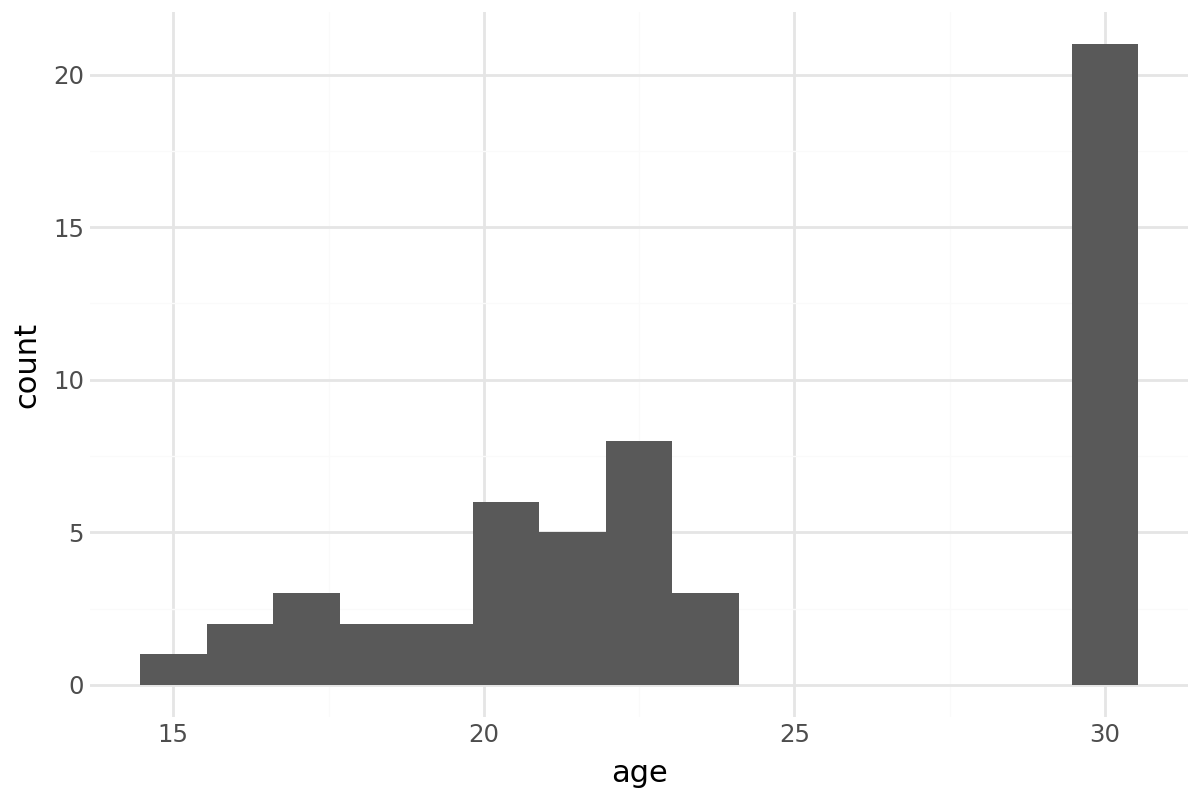

In [27]:
(ggplot(clutch, aes('age'))
+ geom_histogram(bins = 15)
+ theme_minimal()
+ theme(figure_size=(6,4)))

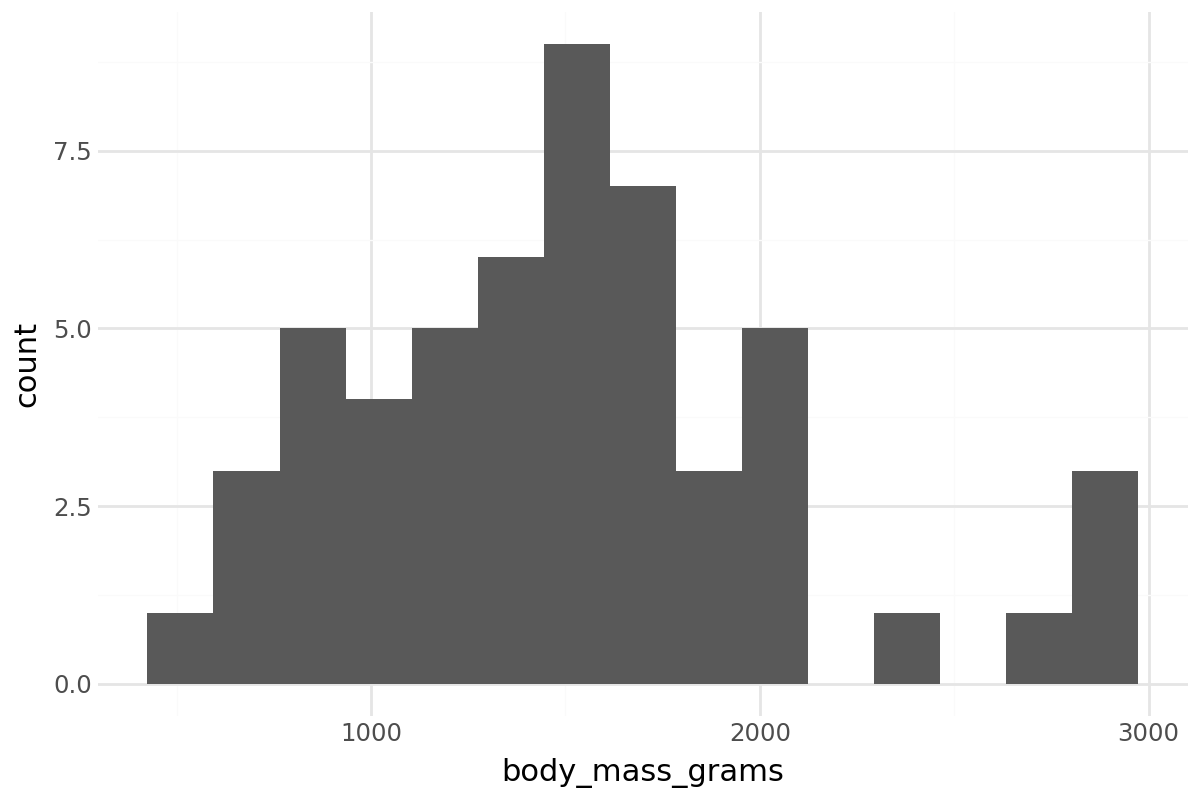

In [28]:
(ggplot(clutch, aes('body_mass_grams'))
+ geom_histogram(bins = 15)
+ theme_minimal()
+ theme(figure_size=(6,4)))

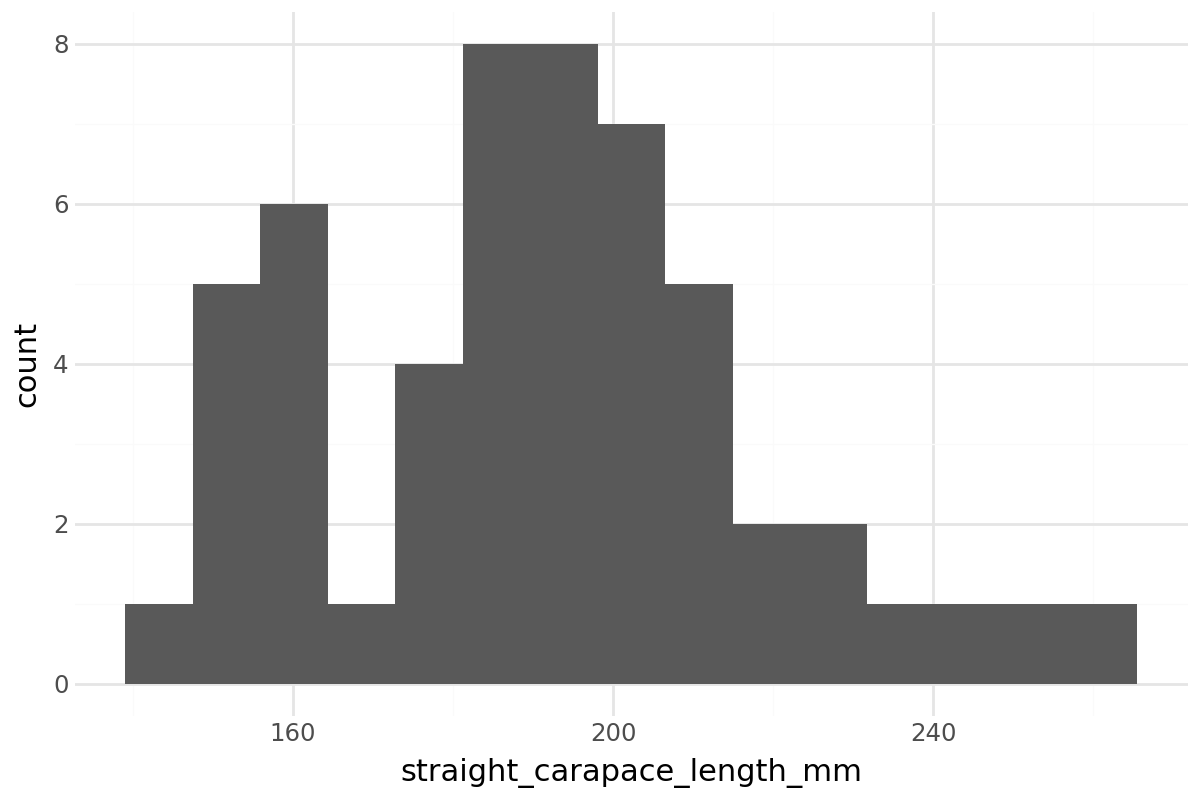

In [29]:
(ggplot(clutch, aes('straight_carapace_length_mm'))
+ geom_histogram(bins = 15)
+ theme_minimal()
+ theme(figure_size=(6,4)))

In [30]:
print(clutch.columns.tolist())
print(body.columns.tolist())

['individual', 'age', 'date', 'locality', 'eggs', 'body_mass_grams', 'straight_carapace_length_mm']
['individual', 'year', 'year_recode', 'season', 'locality', 'sex', 'body_mass_grams', 'body_condition_index', 'straight_carapace_length_mm']


In [31]:
# Maping locality to Island / Mainland

# Plateau refers to the island location (Golem Grad)
# Beach and Konjsko are mainland sites near Lake Prespa.
# Source: study context described in the project overview.

body.loc[:, 'locality_group'] = body['locality'].map({
    'Plateau': 'Island',
    'Beach': 'Mainland',
    'Konjsko': 'Mainland'
})

clutch.loc[:, 'locality_group'] = clutch['locality'].map({
    'Plateau': 'Island',
    'Beach': 'Mainland',
    'Konjsko': 'Mainland'
})

**Q Seasonal Recapture Patterns**

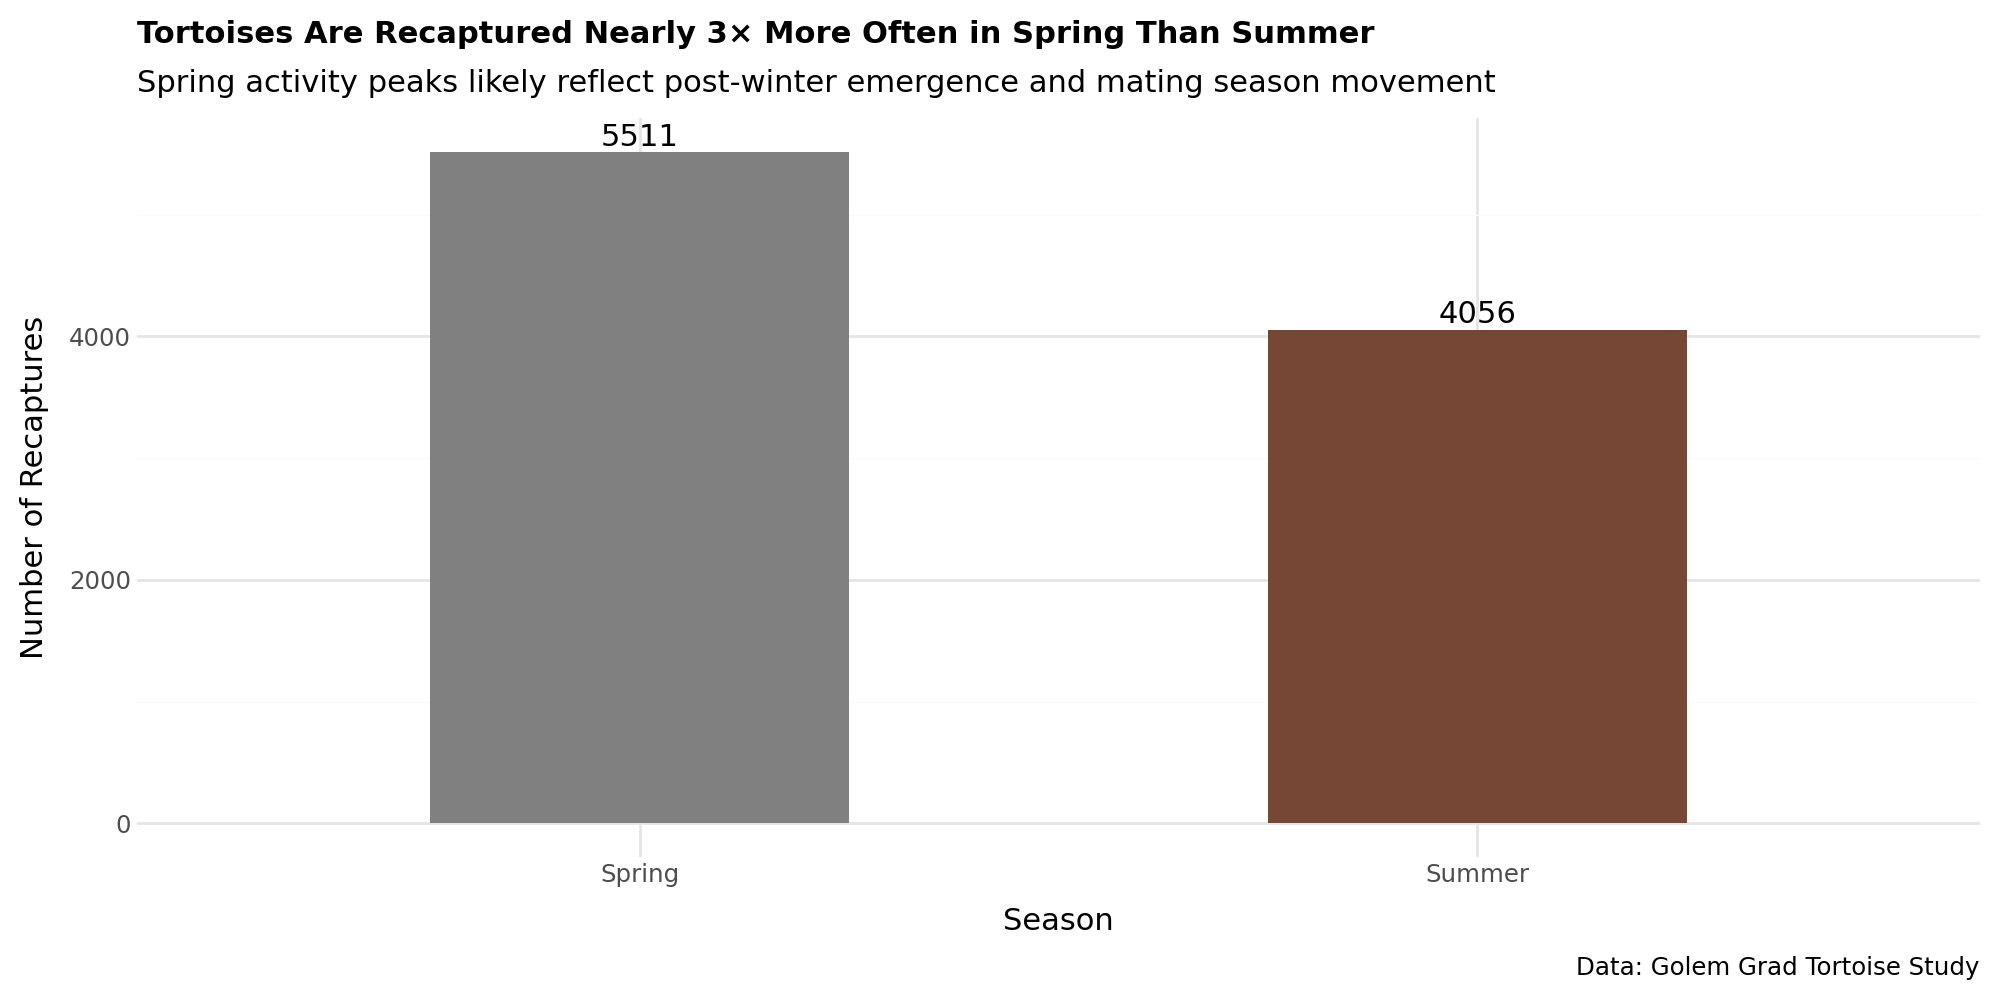

In [32]:
# Filter to true recaptures only (year_recode > 1 means seen before)
recapture = body[body['year_recode'] > 1]
seasonal_counts = recapture['season'].value_counts().reset_index()
seasonal_counts.columns = ['season', 'count']

(ggplot(seasonal_counts, aes(x='season', y='count', fill='season'))
+ geom_col(width=0.5, show_legend=False)
+ geom_text(aes(label='count'), va='bottom', nudge_y=7, size=11)
+ scale_fill_manual(values={'Spring': 'gray', 'Summer': '#754734'})
+ labs(
    title='Tortoises Are Recaptured Nearly 3× More Often in Spring Than Summer',
    subtitle='Spring activity peaks likely reflect post-winter emergence and mating season movement',
    x='Season', 
    y='Number of Recaptures',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 5), 
        plot_title=element_text(weight='bold', size=11)))

Spring recaptures vastly outnumber summer ones. 
Tortoises are cold-blooded and most active in mild temperatures (21–29°C) typical of spring in North Macedonia. 
By summer, heat drives them into hiding, making them harder to find. 
This means that most behavioral observations (including mating harassment) are likely occurring in spring.

---

**Sex Differences in Recapture**

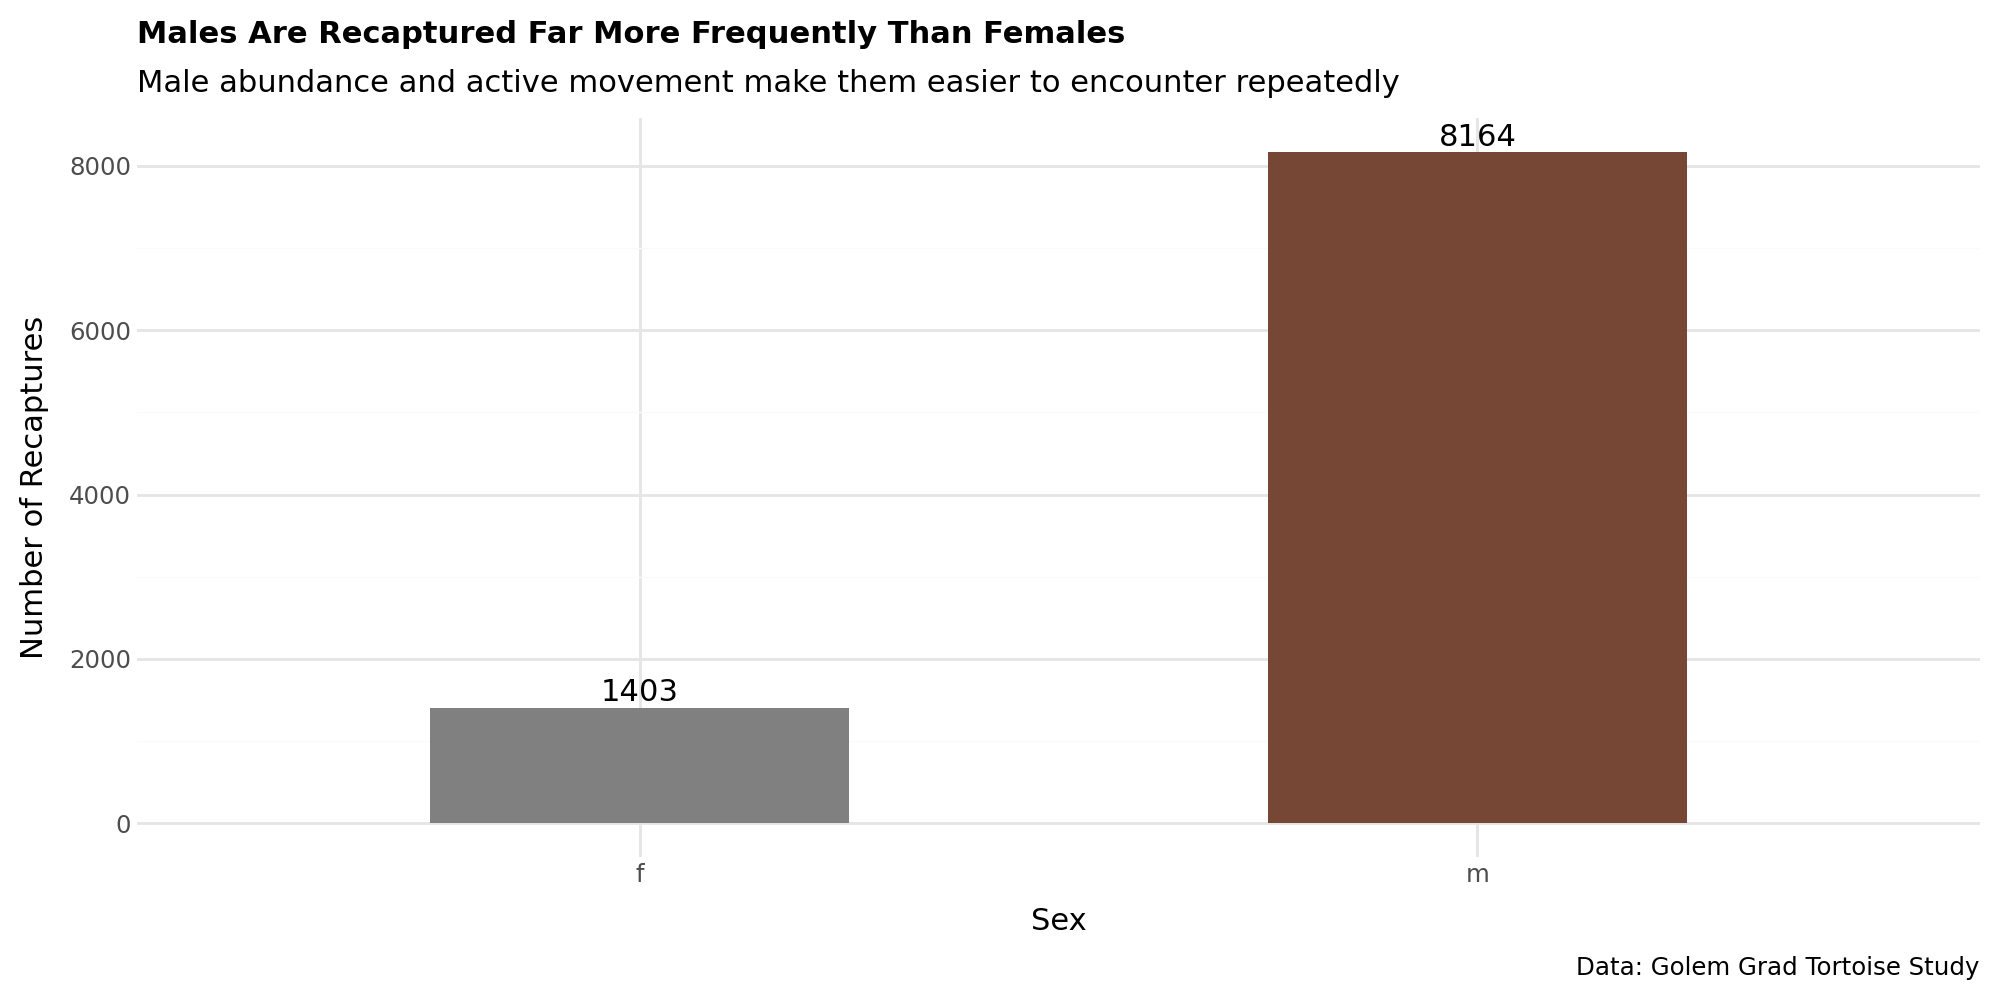

In [33]:
sex_counts = recapture['sex'].value_counts().reset_index()
sex_counts.columns = ['sex', 'count']

(ggplot(sex_counts, aes(x='sex', y='count', fill='sex'))
+ geom_col(width=0.5, show_legend=False)
+ geom_text(aes(label='count'), va='bottom', nudge_y=10, size=11)
+ scale_fill_manual(values={'m': '#754734', 'f': 'gray'})
+ labs(
    title='Males Are Recaptured Far More Frequently Than Females',
    subtitle='Male abundance and active movement make them easier to encounter repeatedly',
    x='Sex', y='Number of Recaptures',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 5), plot_title=element_text(weight='bold', size=11)))

Males dominate the recapture count. This directly reflects the skewed sex ratio on the island, there are simply more males. 

It also reflects behavior: males roam actively in pursuit of females, making them far more visible to researchers. Females, exhausted or injured from harassment, may seek shelter more and be harder to locate.

---

 **Island vs Mainland: Body Mass**

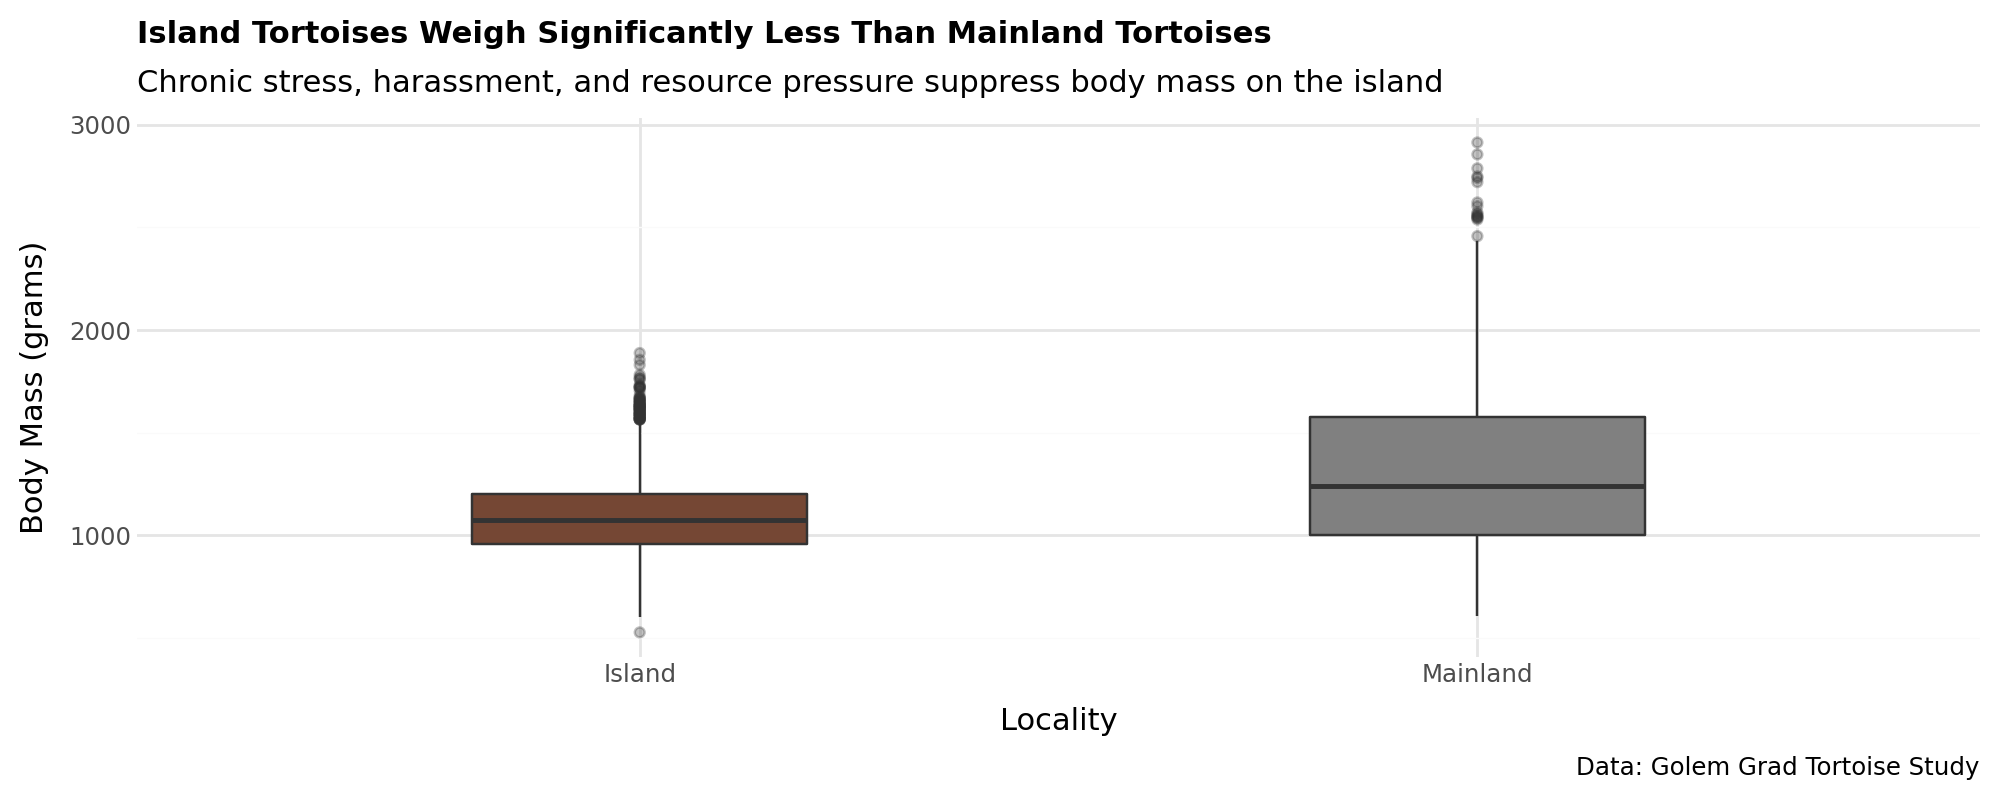

In [34]:
(ggplot(body, aes(x='locality_group', y='body_mass_grams', fill='locality_group'))
+ geom_boxplot(width=0.4, show_legend=False, outlier_alpha=0.3)
+ scale_fill_manual(values={'Island': '#754734', 'Mainland': 'gray'})
+ labs(
    title='Island Tortoises Weigh Significantly Less Than Mainland Tortoises',
    subtitle='Chronic stress, harassment, and resource pressure suppress body mass on the island',
    x='Locality', y='Body Mass (grams)',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4), plot_title=element_text(weight='bold', size=11)))

The box for island tortoises sits lower overall; lower median, lower spread. The mainland population is heavier on average. Body mass is a proxy for health; lighter tortoises have less energy reserves for reproduction and survival. This is consistent with the study's finding that island females are in visibly poorer physical condition due to harassment and reduced foraging time.

---

 **Island vs Mainland: Carapace Length**

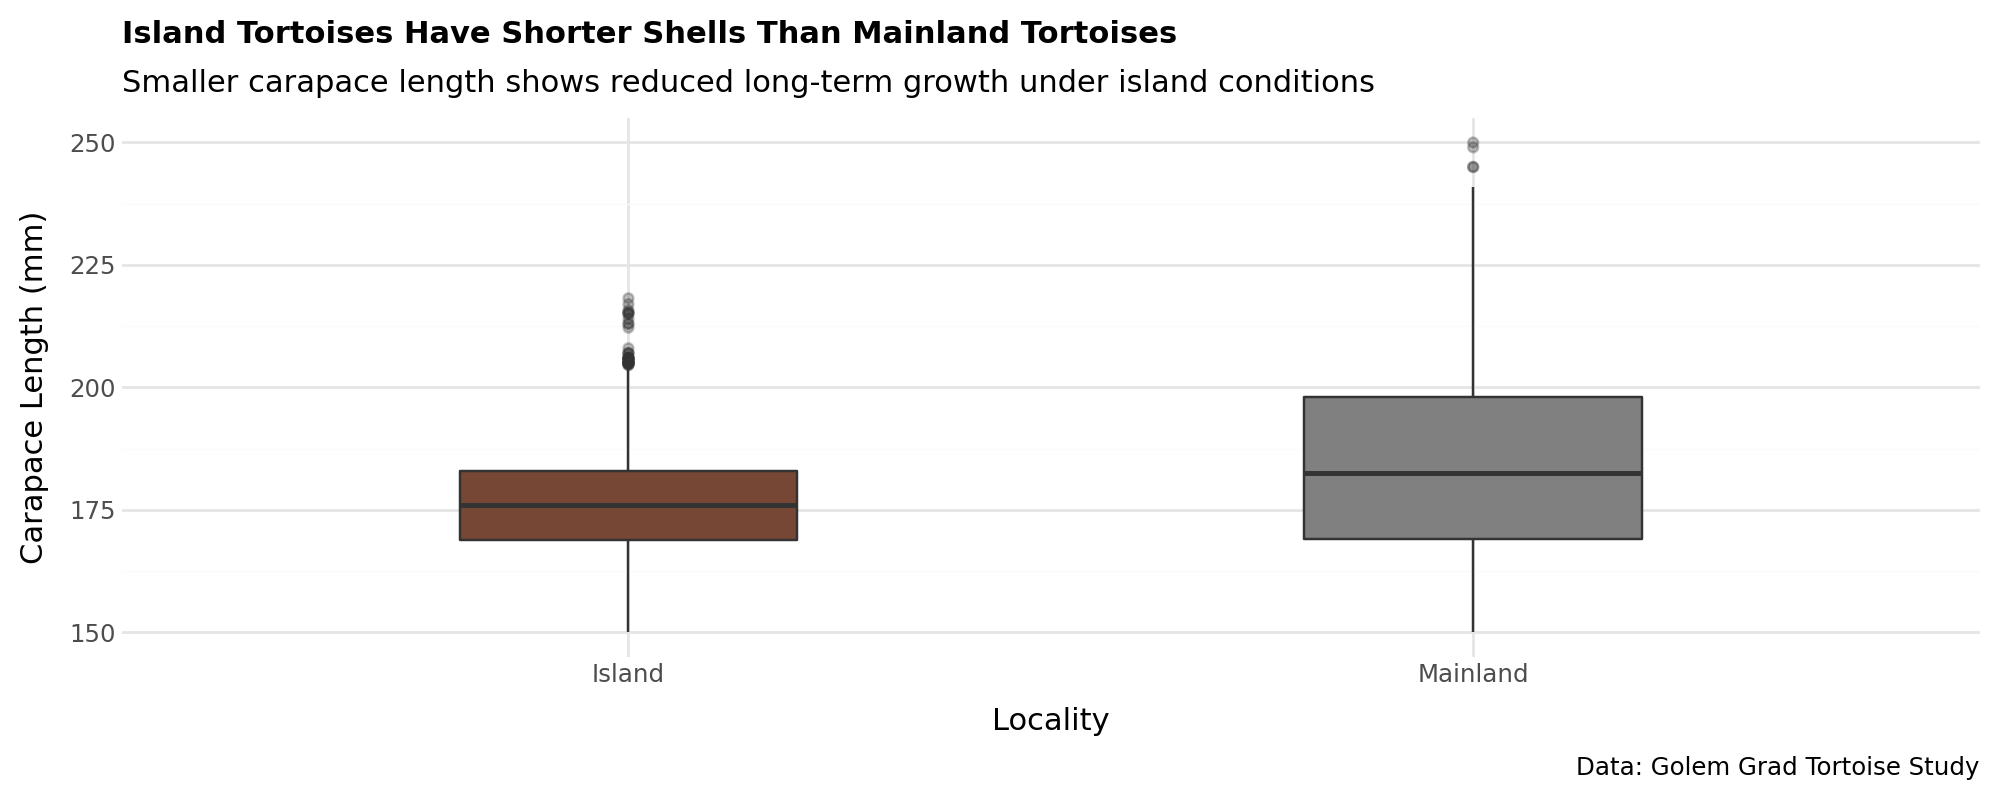

In [35]:
(ggplot(body, aes(x='locality_group', y='straight_carapace_length_mm', fill='locality_group'))
+ geom_boxplot(width=0.4, show_legend=False, outlier_alpha=0.3)
+ scale_fill_manual(values={'Island': '#754734', 'Mainland': 'gray'})
+ labs(
    title='Island Tortoises Have Shorter Shells Than Mainland Tortoises',
    subtitle='Smaller carapace length shows reduced long-term growth under island conditions',
    x='Locality', y='Carapace Length (mm)',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4), plot_title=element_text(weight='bold', size=11)))

Carapace length indicates long-term growth,  it changes slowly over a tortoise's life. Island tortoises having shorter shells suggests they have grown more slowly over time, likely due to chronic resource stress and energy diverted away from growth toward surviving harassment. This is a long-term effect, not just a short-term weight fluctuation.

---


 **Body Condition Index by Sex and Locality**

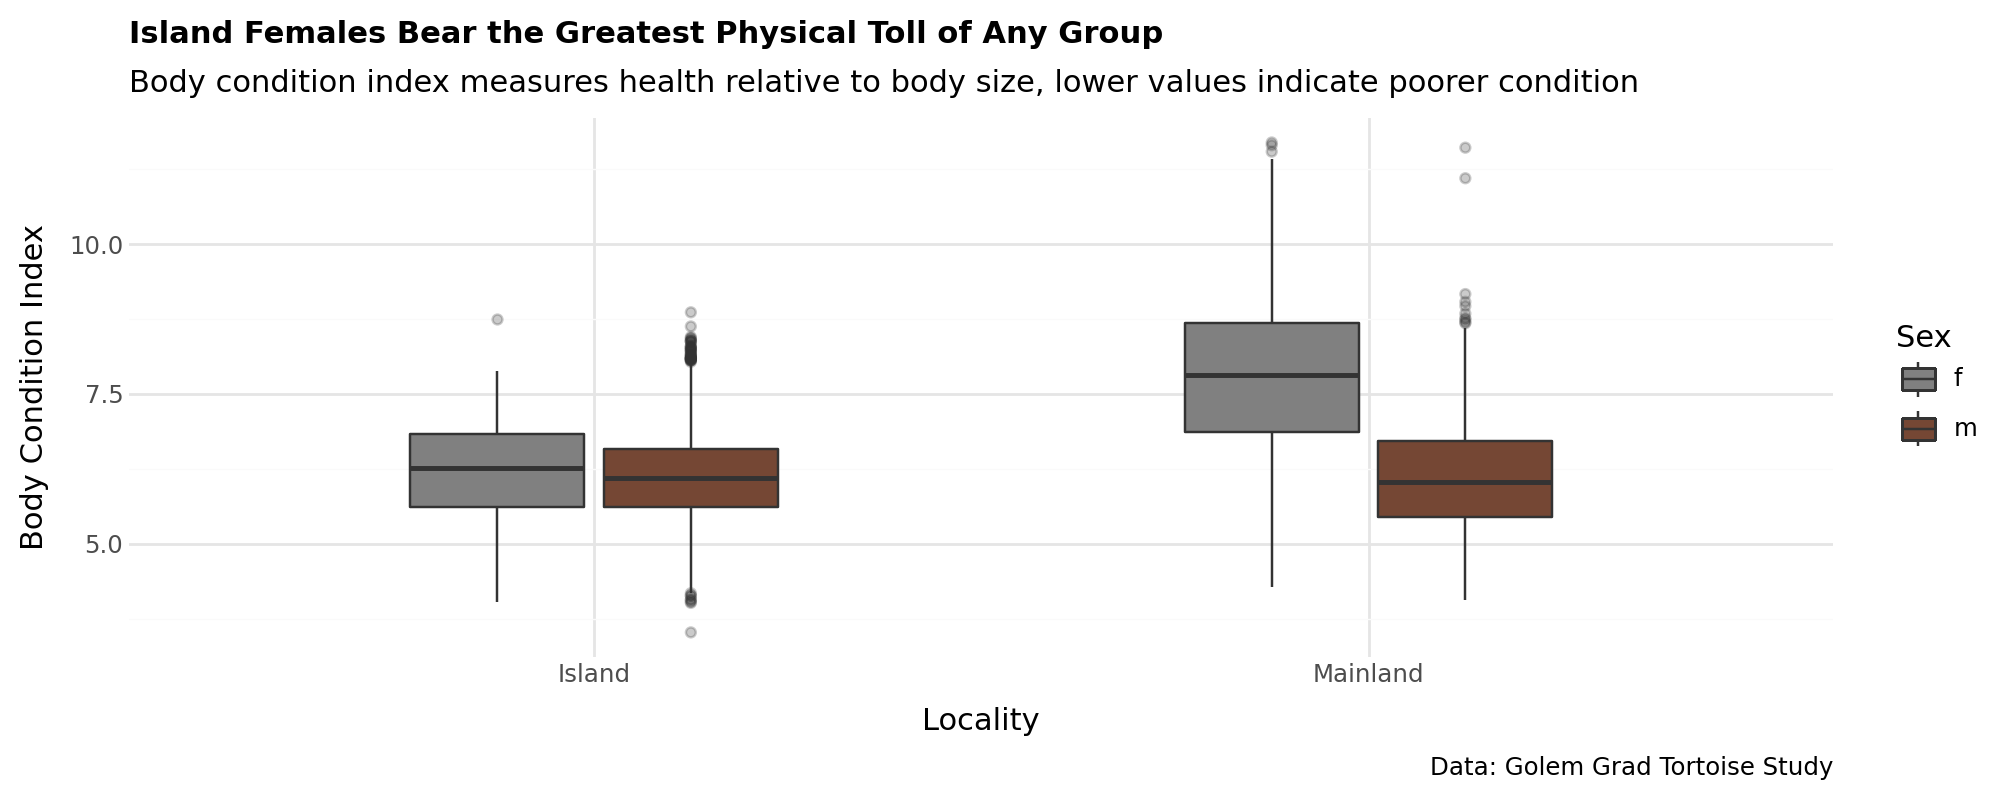

In [36]:
(ggplot(body, aes(x='locality_group', y='body_condition_index', fill='sex'))
+ geom_boxplot(width=0.5, outlier_alpha=0.25)
+ scale_fill_manual(values={'m': '#754734', 'f': 'gray'})
+ labs(
    title='Island Females Bear the Greatest Physical Toll of Any Group',
    subtitle='Body condition index measures health relative to body size, lower values indicate poorer condition',
    x='Locality', y='Body Condition Index',
    fill='Sex',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4), plot_title=element_text(weight='bold', size=11)))

Island females consistently show the lowest body condition index, meaning they are in the worst health relative to their body size. This is a quantitative evidence in the dataset that verifies the harassment effect: that it is specifically island females who suffer most

---

**Seasonal Recapture by Sex**

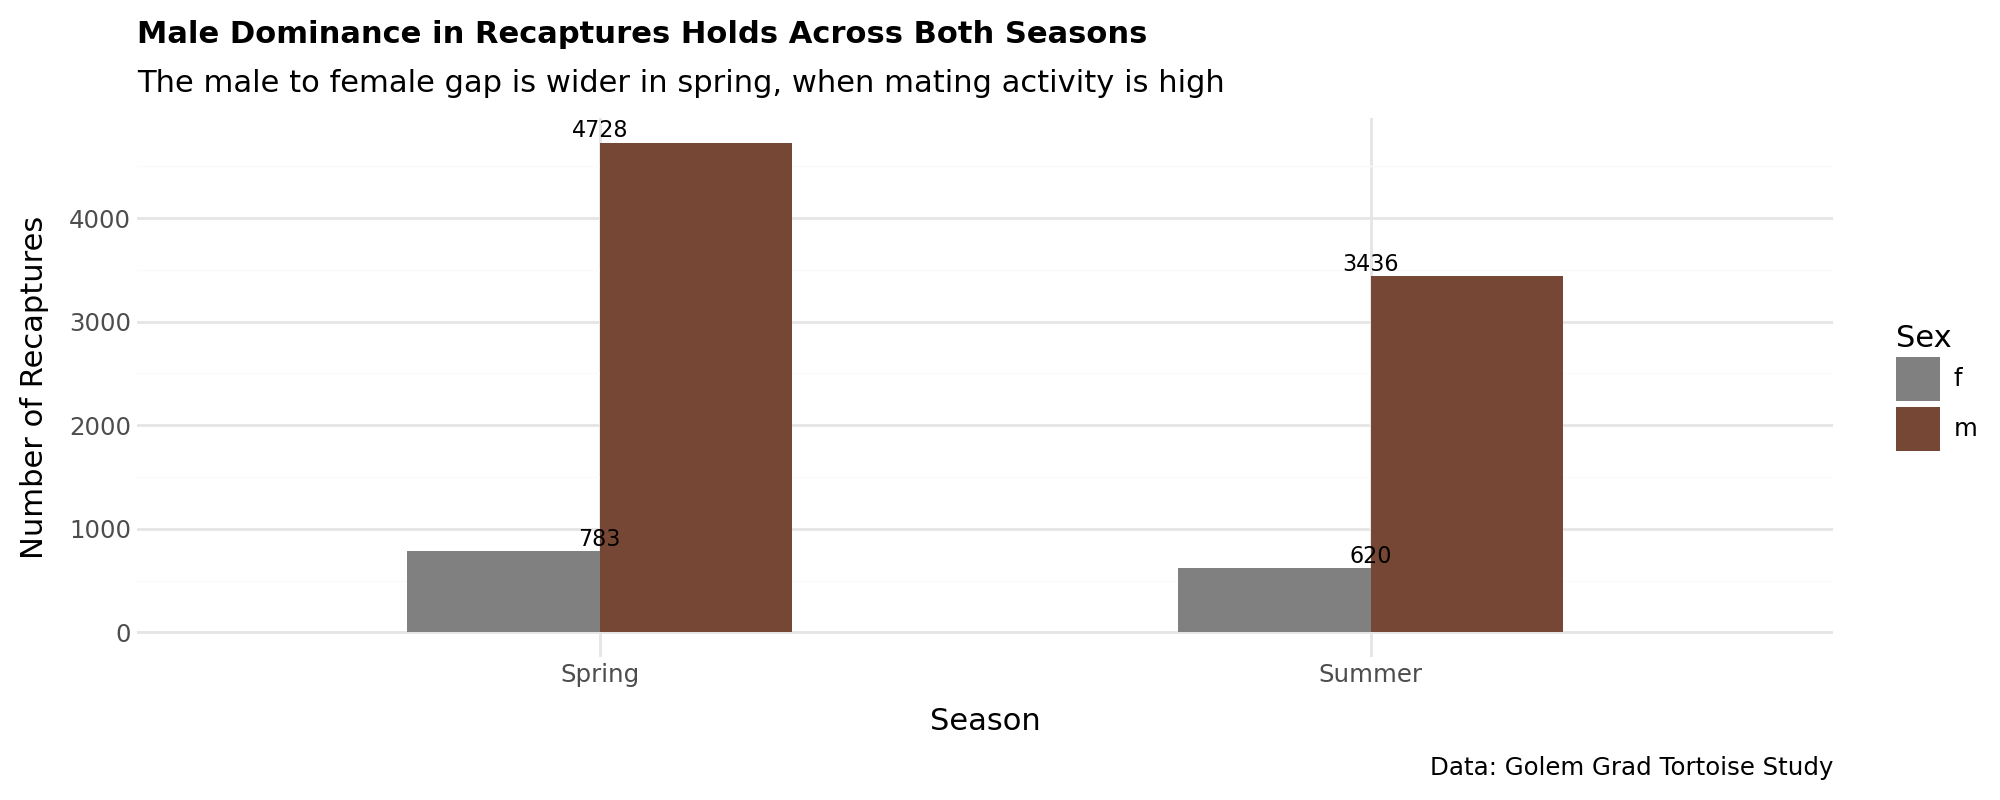

In [37]:
season_sex = recapture.groupby(['season', 'sex']).size().reset_index(name='count')

(ggplot(season_sex, aes(x='season', y='count', fill='sex'))
+ geom_col(position='dodge', width=0.5)
+ geom_text(
    aes(label='count'),
    position=position_dodge(0.7), va='bottom', nudge_y=1, size=8
)
+ scale_fill_manual(values={'m': '#754734', 'f': 'gray'})
+ labs(
    title='Male Dominance in Recaptures Holds Across Both Seasons',
    subtitle='The male to female gap is wider in spring, when mating activity is high',
    x='Season', y='Number of Recaptures',
    fill='Sex',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4),
        plot_title=element_text(weight='bold', size=11)))

Males outnumber female recaptures in both seasons, but the gap is pronounced in spring. This aligns with mating season dynamics : males are roaming aggressively in spring while females are under stress and less mobile. In summer, both sexes reduce activity due to heat, but males still dominate.

---

**Island Body Mass Trend Over Years**

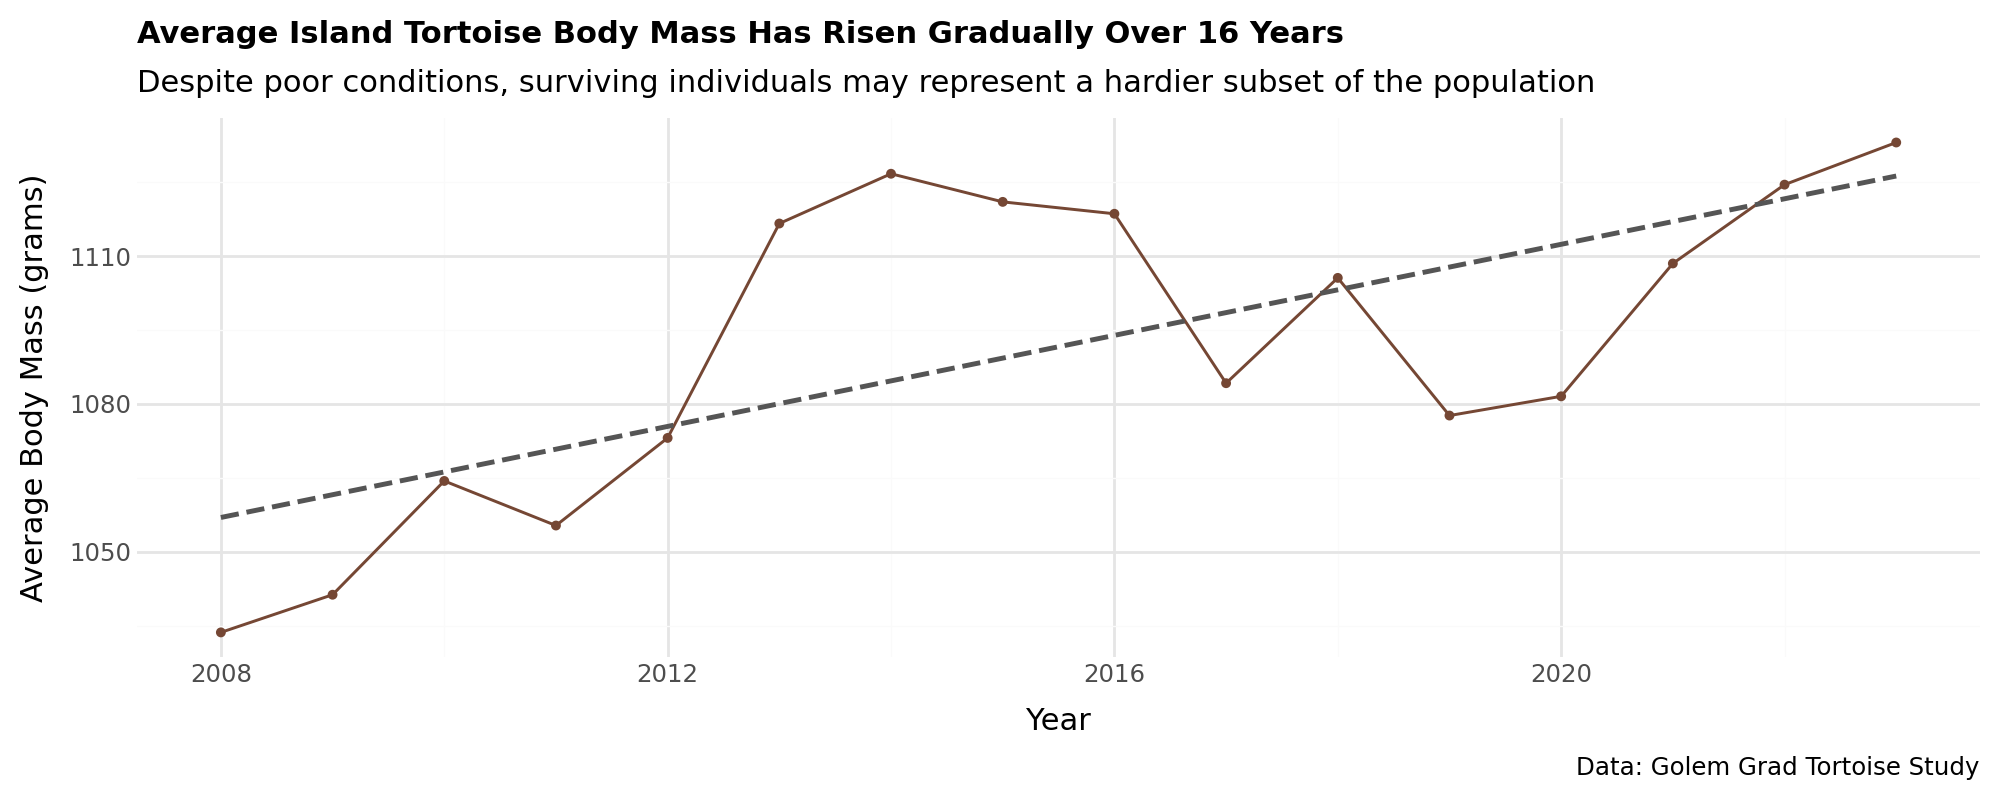

In [38]:
island_trend = (body[body['locality_group'] == 'Island']
                .groupby('year')['body_mass_grams']
                .mean()
                .reset_index(name='avg_mass'))

(ggplot(island_trend, aes(x='year', y='avg_mass'))
+ geom_line(color='#754734', size=0.6)
+ geom_point(color='#754734', size=1)
+ geom_smooth(method='lm', color='#555555', linetype='dashed', se=False)
+ labs(
    title='Average Island Tortoise Body Mass Has Risen Gradually Over 16 Years',
    subtitle='Despite poor conditions, surviving individuals may represent a hardier subset of the population',
    x='Year', 
    y='Average Body Mass (grams)',
    caption='Data: Golem Grad Tortoise Study')
+ theme_minimal()
+ theme(figure_size=(10, 4), 
        plot_title=element_text(weight='bold', size=11)))

Year-by-year average body mass on the island shows a gradual increase over the 16-year study window. Rather than contradicting the study's decline narrative, this likely reflects survivorship bias; as the weakest, lightest females die off or are lost to cliff falls, the individuals that remain tend to be the heavier, more resilient ones, pulling the average upward. The population may be getting physically lighter on entry while appearing heavier on average simply because fewer vulnerable individuals survive long enough to be recaptured. This makes the projected collapse by 2083 even more concerning, the population is shrinking to a hardy but increasingly small remnant.

---

 **Clutch Size vs Body Mass**

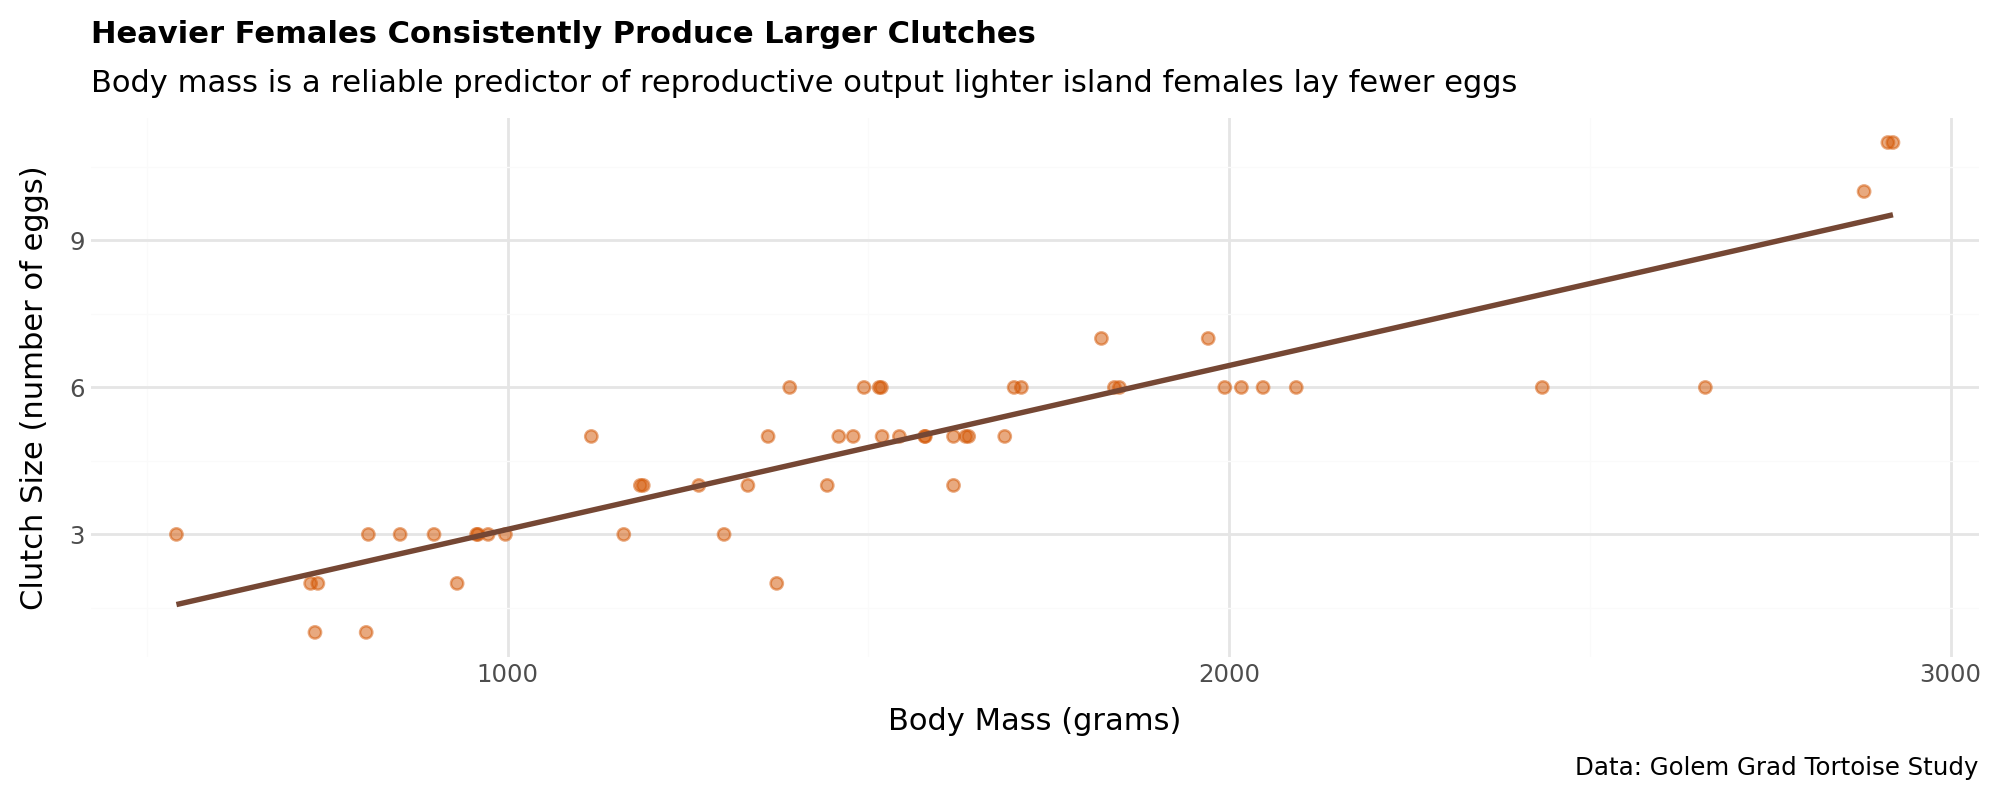

In [43]:
(ggplot(clutch, aes(x='body_mass_grams', y='eggs'))
+ geom_point(alpha=0.5, color='#D35400', size=2)
+ geom_smooth(method='lm', color='#754734', se=False, size=1.1)
+ labs(
    title='Heavier Females Consistently Produce Larger Clutches',
    subtitle='Body mass is a reliable predictor of reproductive output lighter island females lay fewer eggs',
    x='Body Mass (grams)', y='Clutch Size (number of eggs)',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4), plot_title=element_text(weight='bold', size=11)))

Heavier females lay more eggs. This matters enormously for the Golem Grad population: because island females weigh less due to harassment and stress, they also reproduce less. 

The chain of harm is: harassment → lower body mass → smaller clutches → fewer offspring → population decline.


---

  **Age Distribution by Locality**

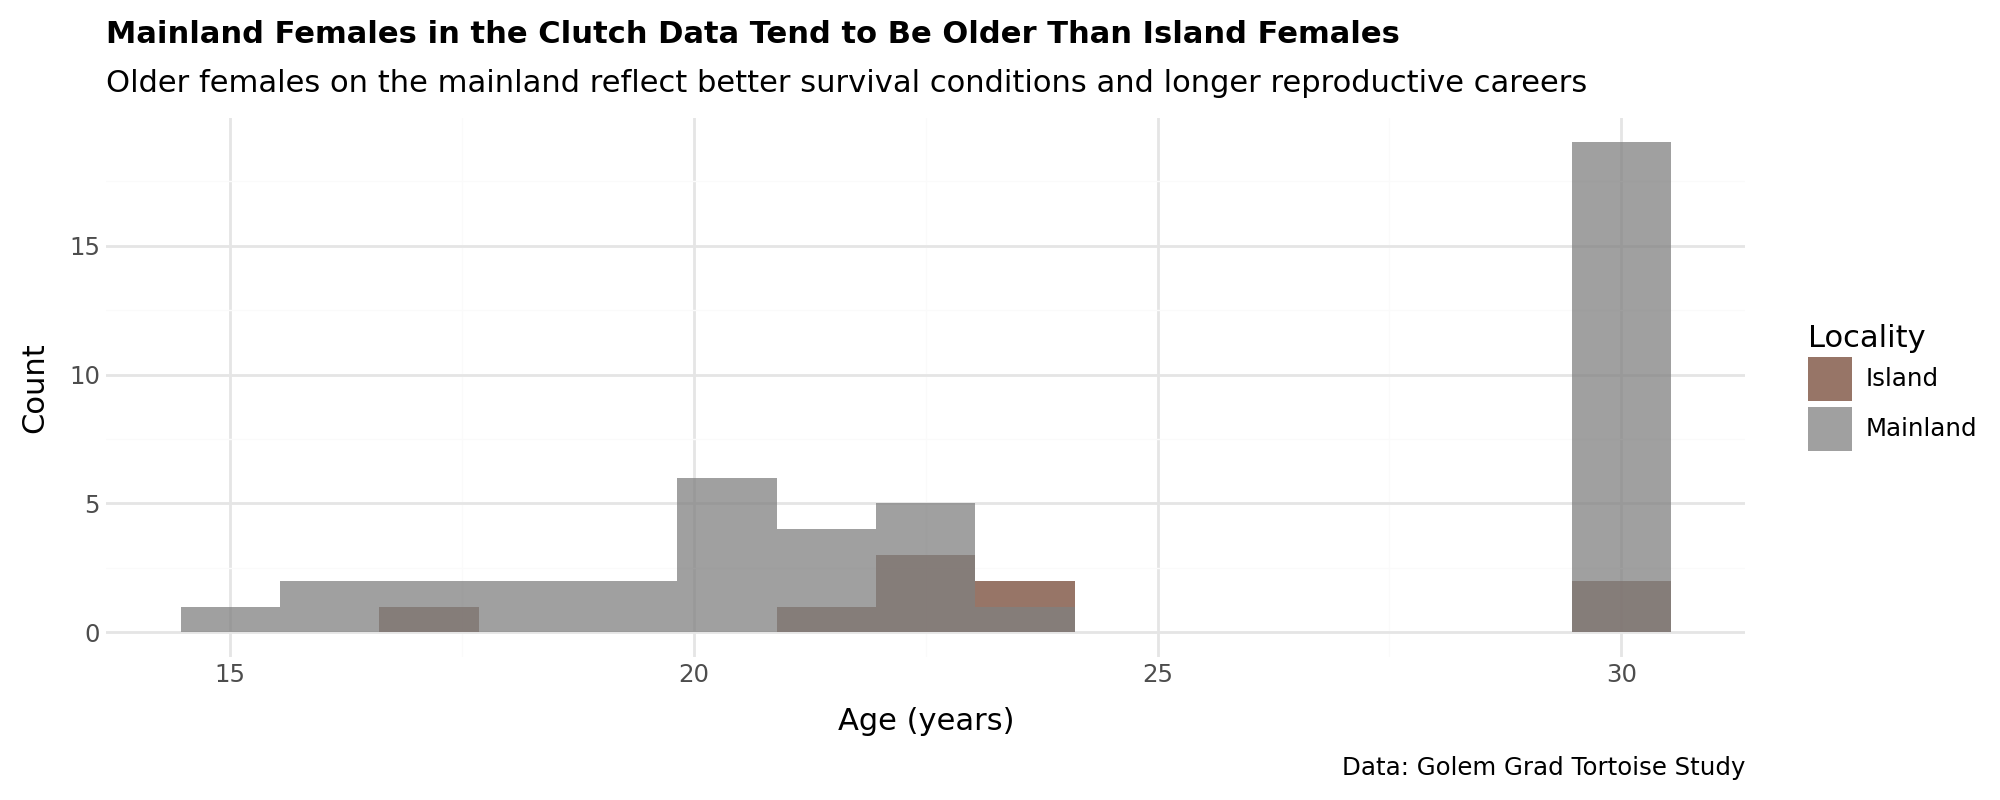

In [44]:
(ggplot(clutch, aes(x='age', fill='locality_group'))
+ geom_histogram(bins=15, alpha=0.75, position='identity')
+ scale_fill_manual(values={'Island': '#754734', 'Mainland': 'gray'})
+ labs(
    title='Mainland Females in the Clutch Data Tend to Be Older Than Island Females',
    subtitle='Older females on the mainland reflect better survival conditions and longer reproductive careers',
    x='Age (years)', y='Count',
    fill='Locality',
    caption='Data: Golem Grad Tortoise Study'
)
+ theme_minimal()
+ theme(figure_size=(10, 4), plot_title=element_text(weight='bold', size=11)))

The age distribution of females who laid eggs skews older on the mainland. Island females that do successfully reproduce tend to be younger, older females on the island may not survive long enough to reach later reproductive years. This is another dimension of the survival pressure island females face.

---

## Conclusion

This analysis of the Golem Grad Hermann's tortoise population reveals a consistent 
and troubling pattern across every dimension of the data.

**Recapture patterns** show that tortoises are most active and most catchable
in spring, when temperatures are optimal and mating activity peaks. Males dominate 
recapture counts in both seasons, directly reflecting the skewed sex ratio and 
the aggressive movement patterns that come with it.

**Physical condition** tells a stark story. Island tortoises are lighter, have 
shorter carapaces, and show lower body condition indices than their mainland 
counterparts and within the island population, females are in the worst condition 
of any group. This is not coincidental: chronic harassment forces females to spend 
energy on escape and recovery rather than foraging and growth.

**Reproduction is severely compromised.** Heavier females lay larger clutches, 
but island females weigh less so they produce fewer eggs. The clutch data 
confirms that mainland females lay significantly more eggs than island females, 
and the island females who do reproduce tend to be younger, suggesting older 
females simply do not survive long enough.

**"The 16 year trend in island body mass** shows a gradual increase, likely reflecting survivorship bias; as weaker individuals are lost, the remaining population skews toward heavier, more resilient tortoises. The population is shrinking to a hardy but increasingly small remnant.
